In [2]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *
from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from IPython.display import display, Math

from scipy.interpolate import CubicSpline



# Na I

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 149757']
**Filtered File List**
8674    /HD149757/BLUE_346/HD149757_w346_blue_20180623...
8717    /HD149757/BLUE_346/HD149757_w346_blue_20150720...
8723    /HD149757/BLUE_346/HD149757_w346_blue_20180623...
8724    /HD149757/BLUE_346/HD149757_w346_blue_20150720...
8727    /HD149757/BLUE_346/HD149757_w346_n30_20180623_...
8733    /HD149757/BLUE_346/HD149757_w346_n30_20150720_...
Name: Filename, dtype: object
6
***Common Objects***
['HD 149757']
**Filtered File List**
8727    /HD149757/BLUE_346/HD149757_w346_n30_20180623_...
8733    /HD149757/BLUE_346/HD149757_w346_n30_20150720_...
Name: Filename, dtype: object
2


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_6729/3090834302.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


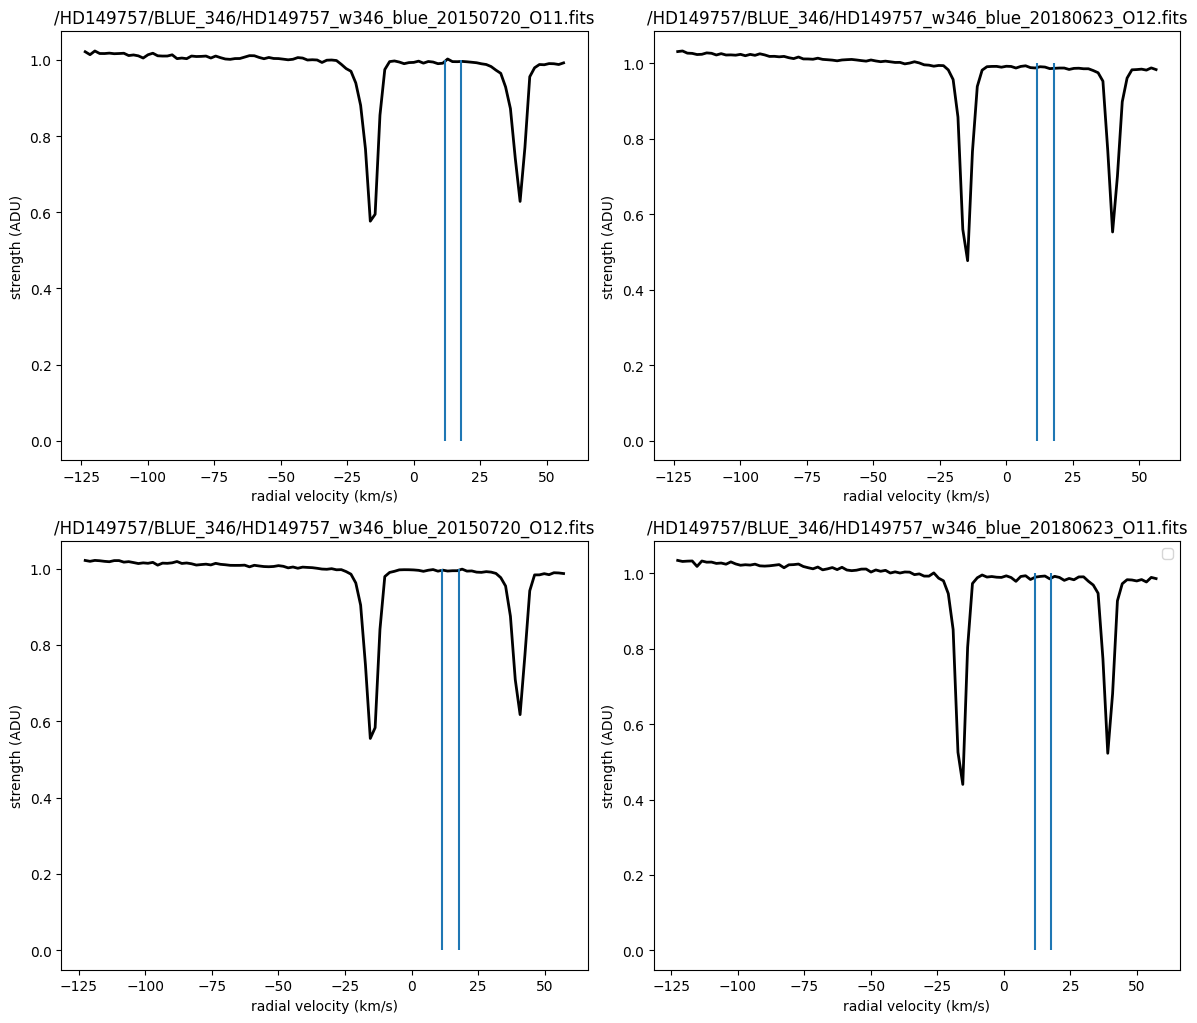

/HD149757/BLUE_346/HD149757_w346_blue_20150720_O11.fits
/HD149757/BLUE_346/HD149757_w346_blue_20180623_O12.fits
/HD149757/BLUE_346/HD149757_w346_blue_20150720_O12.fits
/HD149757/BLUE_346/HD149757_w346_blue_20180623_O11.fits


In [7]:
sightline = "HD 149757"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=3302)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=3302)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [3302.368, 3302.978]
ref_wave = 3302.368
cl_1 = 17.8
cl_2 = 11.6
# cl_3 = -5.4
# cl_3 = -11
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [3301, 3303]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0, ymax=1)

    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# Na II

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 149757']
**Filtered File List**
8610    /HD149757/RED_564/HD149757_w564_redu_20150720_...
8617    /HD149757/RED_564/HD149757_w564_redu_20150720_...
8618    /HD149757/RED_564/HD149757_w564_redu_20180623_...
8625    /HD149757/RED_564/HD149757_w564_n24_20180623_U...
8626    /HD149757/RED_564/HD149757_w564_n24_20150720_U...
8650    /HD149757/RED_564/HD149757_w564_redu_20180623_...
Name: Filename, dtype: object
6
***Common Objects***
['HD 149757']
**Filtered File List**
8625    /HD149757/RED_564/HD149757_w564_n24_20180623_U...
8626    /HD149757/RED_564/HD149757_w564_n24_20150720_U...
Name: Filename, dtype: object
2


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_6729/2521464782.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


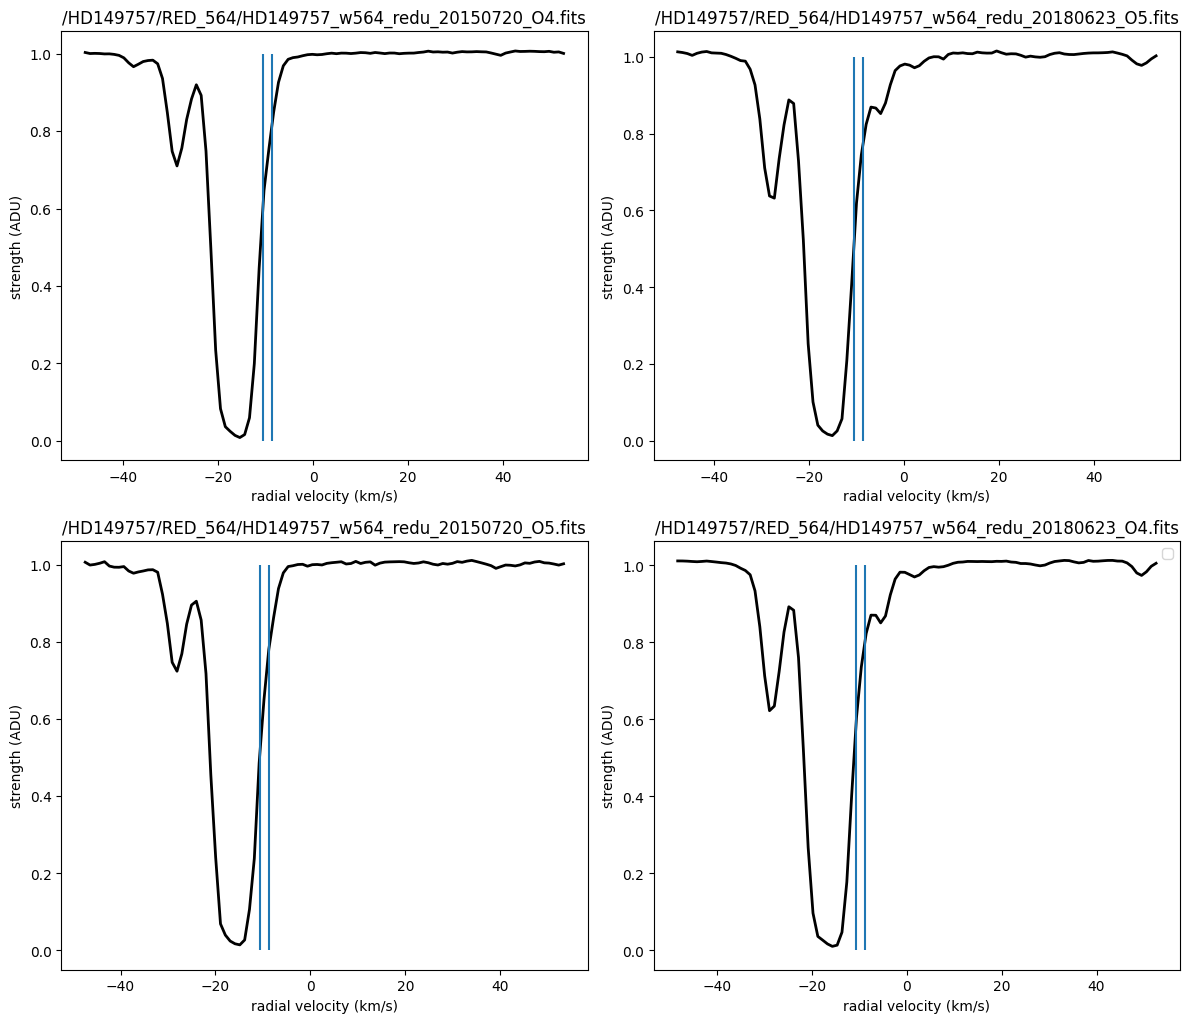

/HD149757/RED_564/HD149757_w564_redu_20150720_O4.fits
/HD149757/RED_564/HD149757_w564_redu_20180623_O5.fits
/HD149757/RED_564/HD149757_w564_redu_20150720_O5.fits
/HD149757/RED_564/HD149757_w564_redu_20180623_O4.fits


In [8]:
sightline = "HD 149757"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=5892)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=5892)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [5889.951, 5895.924]
ref_wave = 5889.951
cl_1 = -8.7
cl_2 = -10.6
# cl_3 = -11
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [5889, 5891]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_3, ymin=0, ymax=1)

    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# K

/Users/ayansahoo/Desktop/MITACS/edibles_spec/DR4
***Common Objects***
['HD 149757']
**Filtered File List**
8742    /HD149757/RED_860/HD149757_w860_redl_20180722_...
8754    /HD149757/RED_860/HD149757_w860_n20_20180731_L...
8755    /HD149757/RED_860/HD149757_w860_n20_20180722_L...
8781    /HD149757/RED_860/HD149757_w860_redl_20150720_...
8790    /HD149757/RED_860/HD149757_w860_redl_20180731_...
8801    /HD149757/RED_860/HD149757_w860_redl_20150720_...
8808    /HD149757/RED_860/HD149757_w860_redl_20180722_...
8835    /HD149757/RED_860/HD149757_w860_n24_20150720_L...
8839    /HD149757/RED_860/HD149757_w860_redl_20180731_...
Name: Filename, dtype: object
9
***Common Objects***
['HD 149757']
**Filtered File List**
8754    /HD149757/RED_860/HD149757_w860_n20_20180731_L...
8755    /HD149757/RED_860/HD149757_w860_n20_20180722_L...
8835    /HD149757/RED_860/HD149757_w860_n24_20150720_L...
Name: Filename, dtype: object
3


/var/folders/x3/g_6bp6fj0vx0dk27lr5119r80000gn/T/ipykernel_6729/1062610299.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


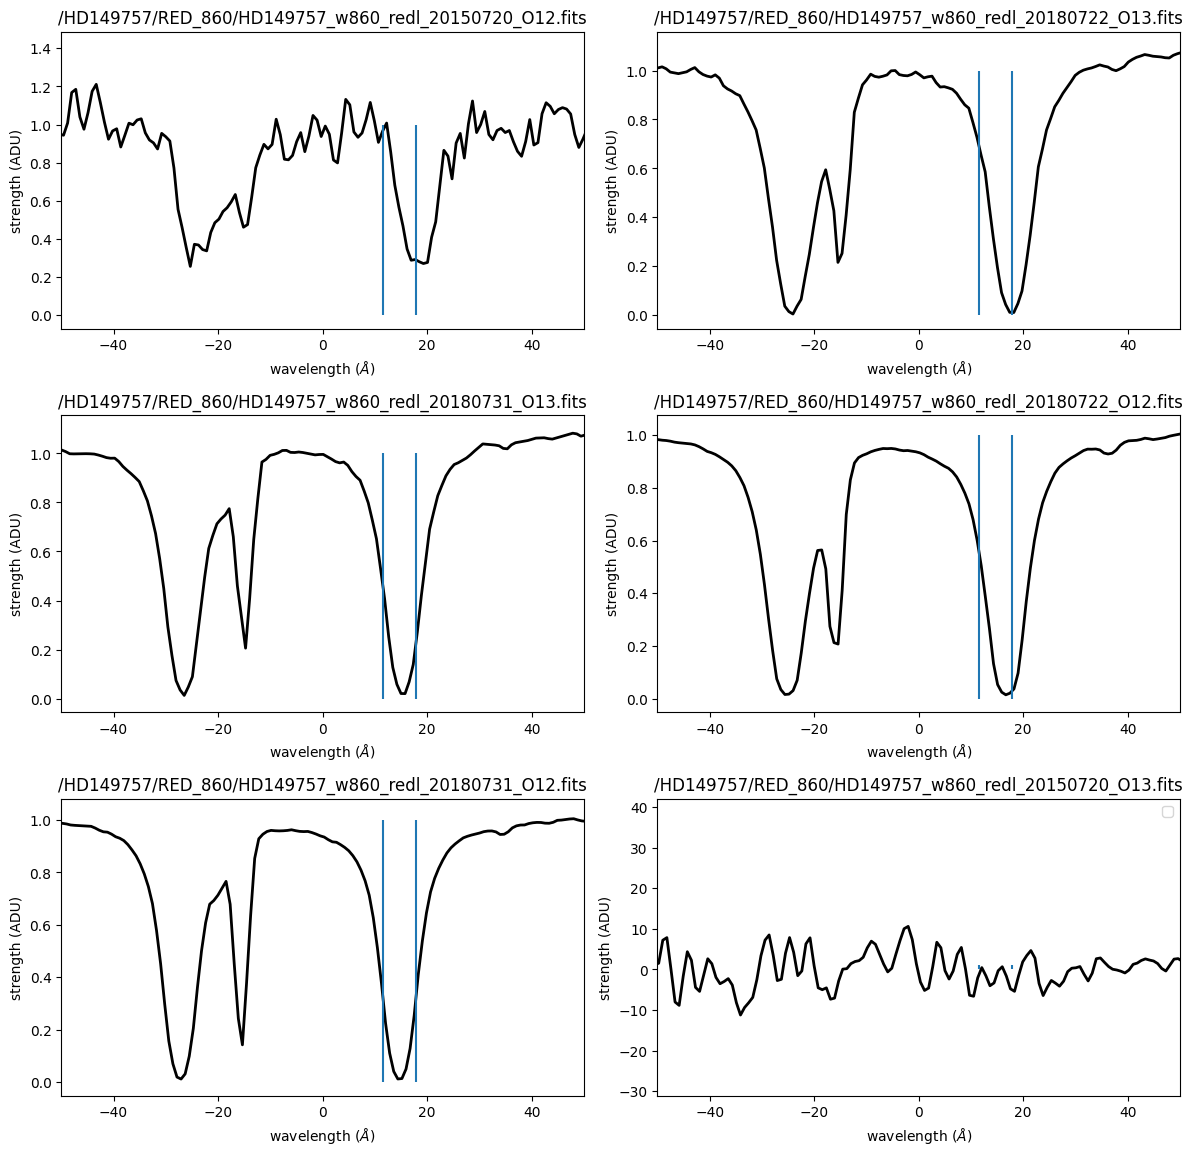

/HD149757/RED_860/HD149757_w860_redl_20150720_O12.fits
/HD149757/RED_860/HD149757_w860_redl_20180722_O13.fits
/HD149757/RED_860/HD149757_w860_redl_20180731_O13.fits
/HD149757/RED_860/HD149757_w860_redl_20180722_O12.fits
/HD149757/RED_860/HD149757_w860_redl_20180731_O12.fits
/HD149757/RED_860/HD149757_w860_redl_20150720_O13.fits


In [9]:
sightline = "HD 149757"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=7680)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=7680)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [7664.899, 7698.965]
ref_wave = 7664.899
cl_1 = 17.8
cl_2 = 11.6
# cl_3 = -30
# cl_3 = -5.4
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [7661, 7670]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0, ymax=1)
    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('wavelength ($\AA$)')
    axs[i].set_ylabel('strength (ADU)')

    axs[i].set_xlim(-50, 50)

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)